# Preditive Model 3:

#### Using Ada Boosting classification modeling to predict if the forecast will understaff in a given week

In [1]:
#Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

In [3]:
#Opening and formating the data
data = pd.read_excel('Mrdak_339Data.xlsx', sheet_name = 'Formatted Data')
#Dropping unnecessary columns
data = data.drop([
'Coffee Actual Sales',
'Actual Sales per Labor Hour.22',
'Actual AHR.22',
'Actual Hours.22',
'Actual % Effective.22',
'Actual Overtime Hours.22',
'Actual Overtime Wages.22',
'Actual Overtime %.22',
'Forecast Fixed Hours.22',
'Forecast Variable Hours.22',
'Earned Hours @ 100%.22',
'Without Fuel Actual Sales',
'Actual Sales per Labor Hour.29',
'Actual AHR.29',
'Actual Hours.29',
'Actual % Effective.29',
'Actual Overtime Hours.29',
'Actual Overtime Wages.29',
'Actual Overtime %.29',
'Forecast Fixed Hours.29',
'Forecast Variable Hours.29',
'Earned Hours @ 100%.29',
'Fuel Actual Sales',
'Actual Sales per Labor Hour.30',
'Actual AHR.30',
'Actual Hours.30',
'Actual % Effective.30',
'Actual Overtime Hours.30',
'Actual Overtime Wages.30',
'Actual Overtime %.30',
'Forecast Fixed Hours.30',
'Forecast Variable Hours.30',
'Earned Hours @ 100%.30',
'Grocery & HBC/GM Actual Sales',
'Actual Sales per Labor Hour.14',
'Actual AHR.14',
'Actual Hours.14',
'Actual % Effective.14',
'Actual Overtime Hours.14',
'Actual Overtime Wages.14',
'Actual Overtime %.14',
'Forecast Fixed Hours.14',
'Forecast Variable Hours.14',
'Earned Hours @ 100%.14'], axis = 1)
#Dropping Average and formatting date
data = data[data['Date'].str.strip() != 'Average']
data["Date"] = pd.to_datetime(data["Date"] + "-1", format = "%G W%V-%u")
data = data.sort_values("Date")

In [4]:
data['week'] = data['Date'].dt.isocalendar().week
data['month'] = data['Date'].dt.month
data['year'] = data['Date'].dt.year

C:\Users\nikol\AppData\Local\Temp\ipykernel_33316\3123566190.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['week'] = data['Date'].dt.isocalendar().week
C:\Users\nikol\AppData\Local\Temp\ipykernel_33316\3123566190.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['month'] = data['Date'].dt.month
C:\Users\nikol\AppData\Local\Temp\ipykernel_33316\3123566190.py:3: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consid

In [5]:
#Combining fixed and variable forecast hours as a total forecast hours
data['Forecast Total Hours'] = data['Forecast Fixed Hours.31'] + data['Forecast Variable Hours.31']
#Creating a variable to measure the forecast error. This will be my target variable
data['Forecast Error'] = data['Actual Hours.31'] - data['Forecast Total Hours']

C:\Users\nikol\AppData\Local\Temp\ipykernel_33316\3575396513.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Forecast Total Hours'] = data['Forecast Fixed Hours.31'] + data['Forecast Variable Hours.31']
C:\Users\nikol\AppData\Local\Temp\ipykernel_33316\3575396513.py:4: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  data['Forecast Error'] = data['Actual Hours.31'] - data['Forecast Total Hours']


In [6]:
data = data.copy()

In [7]:
#Creating a variable to classify over and understaffing within 50 hours difference. 
threshold = 50
data['Staffing Class'] = np.where(
    data['Forecast Error'] > threshold, 'Understaffed', 'Sufficiently Staffed')
#The goal: 
#Understaffed shows 50 or more aditional actual hours than forecasted
#Any less hours and will be classified as not understaffed
#Originally wanted 3 classes, under, over, accurate, but I hypothesize that there is not enough data to train 3 classes. 



#Overstaffed shows 50 or more less actual hours than forecasted
#np.where(data['Forecast Error'] < -threshold, 'Overstaffed', 

In [8]:
X = data[[
        'week',
        'month',
        'year',
        'Grocery Actual Sales',
        'Actual Sales per Labor Hour.3',
        'Dairy Actual Sales',
        'Actual Sales per Labor Hour.4',
        'Frozen Actual Sales',
        'Actual Sales per Labor Hour.5',
        'Liquor Actual Sales',
        'Actual Sales per Labor Hour.6',
        'Natural Foods Actual Sales',
        'Actual Sales per Labor Hour.7',
        'HBC Actual Sales',
        'Actual Sales per Labor Hour.9',
        'Cosmetics Actual Sales',
        'Actual Sales per Labor Hour.10',
        'GM Actual Sales',
        'Actual Sales per Labor Hour.11',
        'Apparel Actual Sales',
        'Actual Sales per Labor Hour.12',
        'Produce Actual Sales',
        'Actual Sales per Labor Hour.15',
        'Floral Actual Sales',
        'Actual Sales per Labor Hour.16',
        'Meat Actual Sales',
        'Actual Sales per Labor Hour.18',
        'Seafood Actual Sales',
        'Actual Sales per Labor Hour.19',
        'Deli Actual Sales',
        'Actual Sales per Labor Hour.21',
        'Bakery Actual Sales',
        'Actual Sales per Labor Hour.24',
        'Rx Actual Sales',
        'Actual Sales per Labor Hour.28'
    ]]
y = data['Staffing Class']

In [9]:
#X_model = X.astype('float64').to_numpy()
#y_model = y.astype(str).to_numpy()

In [10]:
#Forcing datatypes for the model to run correctly. 
X = X.copy()
X['week'] = X['week'].astype('int64')
X['month'] = X['month'].astype('int64')
X['year'] = X['year'].astype('int64')

#y = y.astype(str)

In [11]:
#Setting up the model, split data 1/3 - 2/3 train test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.33, random_state = 24)

In [12]:
#Distinguishing features and setting up pipeline
categorical_features = X.select_dtypes(include=['object', 'category']).columns
numerical_features = X.select_dtypes(include=['int64']).columns

#Preprocessing
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        #('cat', OneHotEncoder(), categorical_features)
    ])

adaboost_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', AdaBoostClassifier(random_state=24, n_estimators=100))
])
#algorithm='SAMME'

In [13]:
#Model results
adaboost_pipeline.fit(X_train, y_train)
y_pred_adaboost = adaboost_pipeline.predict(X_test)
accuracy_adaboost = accuracy_score(y_test, y_pred_adaboost)
print(f"Accuracy: {accuracy_adaboost: .3f}")

Accuracy:  0.635


In [14]:
print(y.value_counts(normalize = True))
print(y.value_counts())

Staffing Class
Understaffed            0.519231
Sufficiently Staffed    0.480769
Name: proportion, dtype: float64
Staffing Class
Understaffed            81
Sufficiently Staffed    75
Name: count, dtype: int64


                      precision    recall  f1-score   support

Sufficiently Staffed       0.64      0.67      0.65        27
        Understaffed       0.62      0.60      0.61        25

            accuracy                           0.63        52
           macro avg       0.63      0.63      0.63        52
        weighted avg       0.63      0.63      0.63        52



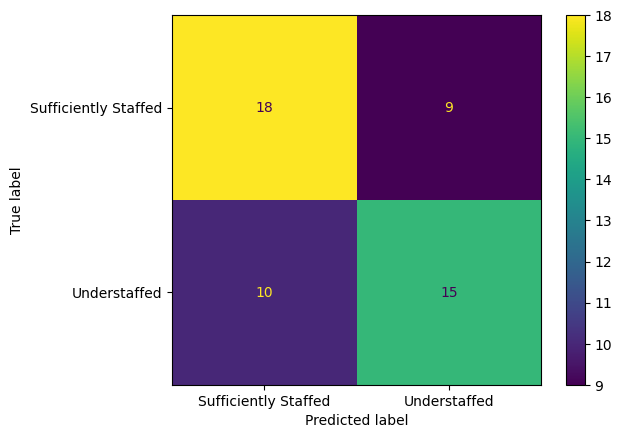

In [15]:
print(classification_report(y_test, y_pred_adaboost))

ConfusionMatrixDisplay.from_estimator(
    adaboost_pipeline,
    X_test,
    y_test
)

### Analysis

This AdaBoost classification model looks to predict when a week's labor forecast will be understaffed or sufficiently staffed. With accuracy of .63 and percision and recalls between .60 - .67, this model shows moderate ability to distinguish and predict understaffed and sufficiently staffed weeks. While it is a plus that the model is balanced between the two classes, there is definetly room for improvement by means of another modeling technique or aquiring a larger dataset. 

In [17]:
#print(X.dtypes)
#print(y.dtype)